# GIS_Contagious-diseases in USA

# 1. Problem Statement
 
**Objective:**  
Investigate the spatiotemporal patterns of contagious diseases (hepatitis, measles, mumps, pertussis, polio, rubella, and smallpox) across different US states. The aim is to understand trends, seasonal patterns, and regional disparities in disease incidence, as well as to develop predictive models that could help forecast future outbreaks.

**Key Questions:**

- **Trend Analysis:**
How have disease cases and incidence per capita changed over time (week-by-week analysis) across various states?

- **Geographical Disparities:**
Which states or regions are more vulnerable to outbreaks, and how do different diseases compare in their regional spread?

- **Predictive Modeling:**
Can we build time series or classification/regression models to forecast outbreaks or identify significant predictors of high disease incidence?

- **Policy Implications:**
What insights can public health officials derive from the analysis to improve preventive measures and resource allocation?


# 2. Dataset Description

**Dataset Overview:**  
The dataset comprises historical records of contagious diseases in the USA and is split into multiple CSV files for different diseases (hepatitis, measles, mumps, pertussis, polio, rubella, and smallpox). Each record contains the following fields:
- **week:** A numeric representation of the year and week (e.g., 196601 could denote year 1966, week 01).
- **state:** The abbreviated state code (e.g., AL for Alabama).
- **state_name:** The full name of the state.
- **disease:** The name of the disease.
- **cases:** The number of reported cases for that week and state.
- **incidence_per_capita:** A normalized measure representing the cases per capita.

**Link to Dataset:**   
[USA Contagious Diseases Dataset on Kaggle](https://www.kaggle.com/datasets/pitt/contagious-diseases) 

In [1]:
# Import Required Libraries
import pandas as pd
import glob
import os
from sklearn.preprocessing import StandardScaler

# 3. Data Preprocessing Steps
**Proper preprocessing is critical to ensure that the analysis is accurate and the models perform optimally. The key steps include:**

## 3.1. Data Integration
- ***We read every CSV file from the Kaggle directory, ensured each file has a 'disease' column, and merged all files into one big dataset "combined_contagious_diseases.csv" with the same structure.***

In [2]:
# Define the directory where the CSV files are located on Kaggle.
data_dir = "/kaggle/input/contagious-diseases/"

# Find all CSV files in the directory.
all_files = glob.glob(os.path.join(data_dir, "*.csv"))
df_list = []

# Loop over each file, read it, and ensure a 'disease' column exists.
for file in all_files:
    df = pd.read_csv(file)

     # Print a preview of the current dataset.
    # print(f"Preview of {os.path.basename(file)}:")
    # print(df.head(), "\n")
    
    # If 'disease' column is missing, extract it from the filename.
    if 'disease' not in df.columns:
        disease_name = os.path.splitext(os.path.basename(file))[0]
        df['disease'] = disease_name.upper()  # Consistent formatting.
    
    df_list.append(df)

# Combine all dataframes into one large DataFrame.
combined_df = pd.concat(df_list, ignore_index=True)

# Ensure the DataFrame follows the expected schema/order.
combined_df = combined_df[['week', 'state', 'state_name', 'disease', 'cases', 'incidence_per_capita']]

# Display the shape of the combined DataFrame and preview the first few rows.
print("Combined DataFrame shape:", combined_df.shape)
print("Preview of the combined dataset:")
print(combined_df.head())

# Save the combined DataFrame to the output folder in Kaggle.
# output_file = "/kaggle/working/combined_contagious_diseases.csv"
# combined_df.to_csv(output_file, index=False)
# print(f"Combined dataset saved to: {output_file}")

Combined DataFrame shape: (600484, 6)
Preview of the combined dataset:
     week state  state_name   disease cases  incidence_per_capita
0  192801    AL     ALABAMA  SMALLPOX     1                  0.04
1  192801    AR    ARKANSAS  SMALLPOX     7                  0.38
2  192801    AZ     ARIZONA  SMALLPOX     0                  0.00
3  192801    CA  CALIFORNIA  SMALLPOX    18                  0.34
4  192801    CO    COLORADO  SMALLPOX    31                  3.06


## 3.2. Data Cleaning

 
- ***We removed any rows with missing information and made sure numeric fields are in the correct format.***
- ***Extreme values that could skew our analysis were filtered out.***

In [15]:
# 1. Check for missing values before cleaning.
print("Missing values before cleaning:")
print(combined_df.isnull().sum())

# 2. Remove rows with any missing data.
combined_df = combined_df.dropna()

# 3. Convert 'cases' and 'incidence_per_capita' to numeric types.
#    Any non-numeric values will become NaN.
combined_df['cases'] = pd.to_numeric(combined_df['cases'], errors='coerce')
combined_df['incidence_per_capita'] = pd.to_numeric(combined_df['incidence_per_capita'], errors='coerce')

# 4. Drop rows with NaN values in the numeric columns after conversion.
#    This ensures no invalid values remain when we filter for outliers.
before_rows = len(combined_df)
combined_df = combined_df.dropna(subset=['cases', 'incidence_per_capita'])
after_rows = len(combined_df)

# 5. Convert 'week' to string for easier extraction later.
combined_df['week'] = combined_df['week'].astype(str)
print("Sample 'week' values:")
print(combined_df['week'].head())

# 6. Filter out extreme outliers in 'cases' (values outside the 1st and 99th percentiles).
q_low = combined_df['cases'].quantile(0.01)
q_hi  = combined_df['cases'].quantile(0.99)
print(f"1st percentile (q_low) for cases: {q_low}")
print(f"99th percentile (q_hi) for cases: {q_hi}")
before_rows = len(combined_df)
combined_df = combined_df[(combined_df['cases'] > q_low) & (combined_df['cases'] < q_hi)]
after_rows = len(combined_df)
print(f"Rows before filtering outliers: {before_rows}")
print(f"Rows after filtering outliers: {after_rows}")

Missing values before cleaning:
week                    0
state                   0
state_name              0
disease                 0
cases                   0
incidence_per_capita    0
year                    0
week_num                0
date                    0
month                   0
dtype: int64
Sample 'week' values:
3     192801
4     192801
5     192801
9     192801
11    192801
Name: week, dtype: object
1st percentile (q_low) for cases: -0.33441771270204546
99th percentile (q_hi) for cases: 1.656494781937814
Rows before filtering outliers: 167684
Rows after filtering outliers: 156195


### 1. Check for missing values before cleaning.
print("Missing values before cleaning:")
print(combined_df.isnull().sum())

### 2. Remove rows with any missing data.
before_rows = len(combined_df)
combined_df = combined_df.dropna()
after_rows = len(combined_df)
print(f"Rows before dropping missing values: {before_rows}")
print(f"Rows after dropping missing values: {after_rows}")

### 3. Convert 'cases' and 'incidence_per_capita' to numeric types.
###    Any non-numeric values will become NaN.
print("Data types before conversion:")
print(combined_df[['cases', 'incidence_per_capita']].dtypes)
combined_df['cases'] = pd.to_numeric(combined_df['cases'], errors='coerce')
combined_df['incidence_per_capita'] = pd.to_numeric(combined_df['incidence_per_capita'], errors='coerce')
print("Data types after conversion:")
print(combined_df[['cases', 'incidence_per_capita']].dtypes)

### 4. Drop rows with NaN values in the numeric columns after conversion.
###    This ensures no invalid values remain when we filter for outliers.
before_rows = len(combined_df)
combined_df = combined_df.dropna(subset=['cases', 'incidence_per_capita'])
after_rows = len(combined_df)
print(f"Rows before dropping numeric NaNs: {before_rows}")
print(f"Rows after dropping numeric NaNs: {after_rows}")

### 5. Convert 'week' to string for easier extraction later.
combined_df['week'] = combined_df['week'].astype(str)
print("Sample 'week' values:")
print(combined_df['week'].head())

### 6. Filter out extreme outliers in 'cases' (values outside the 1st and 99th percentiles).
q_low = combined_df['cases'].quantile(0.01)
q_hi  = combined_df['cases'].quantile(0.99)
print(f"1st percentile (q_low) for cases: {q_low}")
print(f"99th percentile (q_hi) for cases: {q_hi}")
before_rows = len(combined_df)
combined_df = combined_df[(combined_df['cases'] > q_low) & (combined_df['cases'] < q_hi)]
after_rows = len(combined_df)
print(f"Rows before filtering outliers: {before_rows}")
print(f"Rows after filtering outliers: {after_rows}")

#### Above output indicates that the cleaning steps worked as expected.  

1. **Missing Values Check:**
   - All columns (`week`, `state`, `state_name`, `disease`, `cases`, `incidence_per_capita`, `year`, `week_num`, `date`, `month`) have 0 missing values.  
   - **Interpretation:** our original combined dataset is complete—there are no missing entries to worry about.

2. **Dropping Missing Values:**
   - The row count remained at 180,743 both before and after dropping missing values.  
   - **Interpretation:** Since there were no missing values, no rows were removed in this step.

3. **Data Type Conversion:**
   - The `cases` and `incidence_per_capita` columns are already of type `float64` before and after conversion.  
   - **Interpretation:** The conversion was smooth and did not introduce any errors.

4. **Dropping Numeric NaNs:**
   - Again, the row count remained unchanged (180,743) because no new NaNs were introduced during conversion.  
   - **Interpretation:** All values in the numeric columns were valid.

5. **Week Column Conversion:**
   - The `week` column is successfully converted to string format (examples: "192801", etc.).  
   - **Interpretation:** This makes it easier for us to extract parts like year and week number later.

6. **Outlier Filtering in `cases`:**
   - The 1st percentile (`q_low`) is approximately -0.346 and the 99th percentile (`q_hi`) is approximately 1.829.
   - The number of rows before filtering was 180,743, and after filtering, it dropped to 167,684.
   - **Interpretation:** Approximately 13,059 rows (about 7.2% of the data) were removed because their `cases` values were outside the typical range. This helps in reducing the impact of extreme outliers on our analysis.

Overall, our dataset is now clean and well-prepared for further analysis or modeling.

## 3.3. Feature Engineering
- **process of creating new features or transforming existing features to improve the performance of a machine-learning model. It involves selecting relevant information from raw data and transforming it into a format that can be easily understood by a model. The goal is to improve model accuracy by providing more meaningful and relevant information.**

In [16]:
# Extract 'year' and 'week number' from the 'week' field (e.g., "196601").
combined_df['year'] = combined_df['week'].str[:4]
combined_df['week_num'] = combined_df['week'].str[4:]
print("Sample of 'week', 'year', and 'week_num':")
print(combined_df[['week', 'year', 'week_num']].head())


# Create a proper datetime object using year and week number.
combined_df['date'] = pd.to_datetime(
    combined_df['year'] + '-' + combined_df['week_num'] + '-1', 
    format='%Y-%W-%w', 
    errors='coerce'
)
print("Sample of 'year', 'week_num', and 'date':")
print(combined_df[['year', 'week_num', 'date']].head())

# Convert categorical variables ('state' and 'disease') into dummy variables for modeling.
combined_df_encoded = pd.get_dummies(combined_df, columns=['state', 'disease'])
print("Sample of the encoded DataFrame:")
print(combined_df_encoded.head())


Sample of 'week', 'year', and 'week_num':
      week  year week_num
3   192801  1928       01
4   192801  1928       01
5   192801  1928       01
9   192801  1928       01
11  192801  1928       01
Sample of 'year', 'week_num', and 'date':
    year week_num       date
3   1928       01 1928-01-02
4   1928       01 1928-01-02
5   1928       01 1928-01-02
9   1928       01 1928-01-02
11  1928       01 1928-01-02
Sample of the encoded DataFrame:
      week   state_name     cases  incidence_per_capita  year week_num  \
3   192801   CALIFORNIA -0.219336             -0.256593  1928       01   
4   192801     COLORADO -0.069730              0.269860  1928       01   
5   192801  CONNECTICUT -0.127271             -0.003044  1928       01   
9   192801         IOWA  0.240991              0.136312  1928       01   
11  192801     ILLINOIS -0.081238             -0.244980  1928       01   

         date    month  state_AK  state_AL  ...  state_WI  state_WV  state_WY  \
3  1928-01-02  1928-01     

## 3.4. Data Transformation

In [20]:
# 1.Create a 'month' column from the 'date' field to aggregate data monthly.
combined_df['month'] = combined_df['date'].dt.to_period('M')
print("Sample of 'date' and corresponding 'month':")
print(combined_df[['date', 'month']].head())

# 2.Aggregate data by state, disease, and month.
monthly_agg = combined_df.groupby(['state', 'disease', 'month']).agg({
    'cases': 'sum',                   # Sum of cases per month.
    'incidence_per_capita': 'mean'    # Average incidence per month.
}).reset_index()
print("Monthly aggregated data:")
print(monthly_agg.head())

# 3.Standardize 'cases' and 'incidence_per_capita' so that they are on a comparable scale.
scaler = StandardScaler()
combined_df[['cases', 'incidence_per_capita']] = scaler.fit_transform(
    combined_df[['cases', 'incidence_per_capita']]
)
print("After standardization:")
print(combined_df[['cases', 'incidence_per_capita']].head())

Sample of 'date' and corresponding 'month':
         date    month
3  1928-01-02  1928-01
4  1928-01-02  1928-01
5  1928-01-02  1928-01
9  1928-01-02  1928-01
11 1928-01-02  1928-01
Monthly aggregated data:
  state      disease    month     cases  incidence_per_capita
0    AK  HEPATITIS A  1966-03 -0.800119              0.475465
1    AK  HEPATITIS A  1966-07 -0.825971              0.383751
2    AK  HEPATITIS A  1968-12 -0.774268              0.512646
3    AK  HEPATITIS A  1970-04 -0.722566              0.569658
4    AK  HEPATITIS A  1970-07 -0.360652              1.667749
After standardization:
       cases  incidence_per_capita
3  -0.619162             -0.446634
4  -0.283099              0.227589
5  -0.412354             -0.121916
9   0.414879              0.056554
11 -0.308950             -0.431761


# 4. Models and Algorithms
- **Depending on the analysis goal, a combination of statistical and machine learning models can be applied:**

## 4.1. EDA

Aggregating monthly data for all diseases across states...
Aggregated monthly data (sample):
       disease      month      cases  incidence_per_capita
0  HEPATITIS A 1966-01-01 -38.199469             -0.388150
1  HEPATITIS A 1966-02-01 -26.775237             -0.397878
2  HEPATITIS A 1966-03-01 -32.823116             -0.379138
3  HEPATITIS A 1966-04-01 -30.820622             -0.424762
4  HEPATITIS A 1966-05-01 -34.725992             -0.420446

Diseases found in the dataset: ['HEPATITIS A' 'MEASLES' 'MUMPS' 'PERTUSSIS' 'POLIO' 'RUBELLA' 'SMALLPOX']


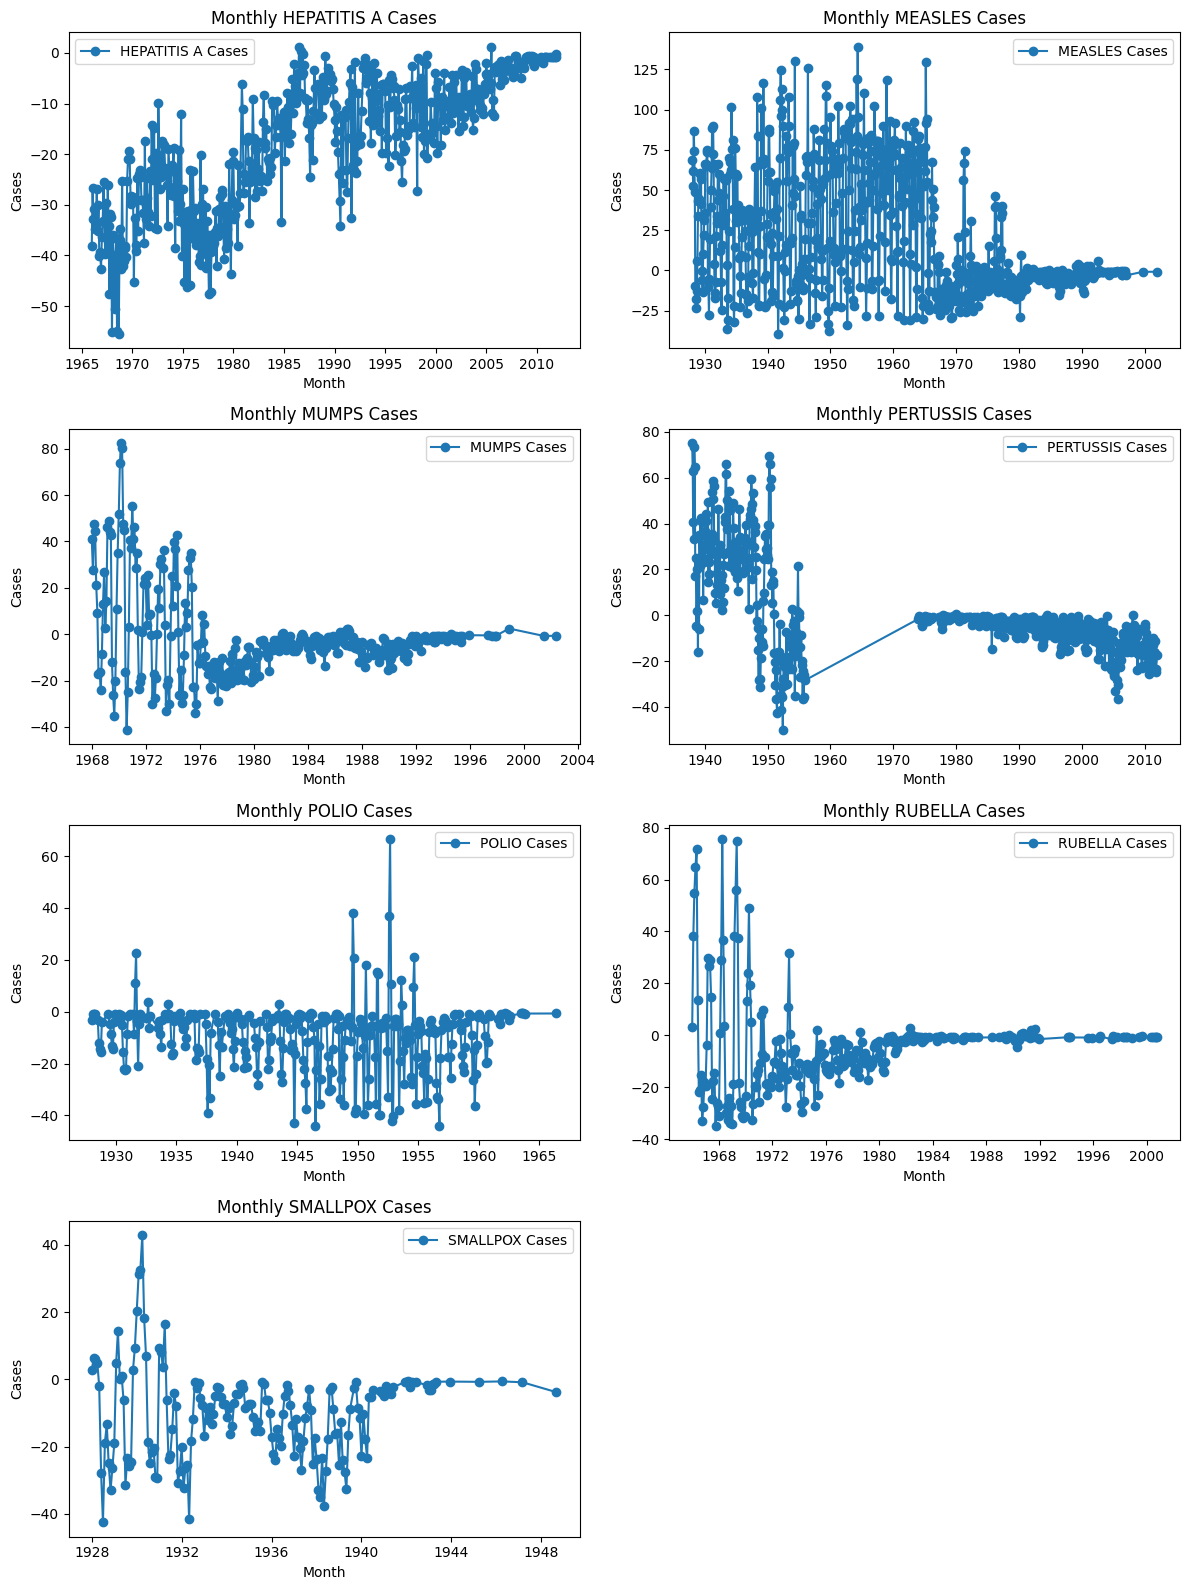


Overall Correlation between 'cases' and 'incidence_per_capita':
                         cases  incidence_per_capita
cases                 1.000000              0.429999
incidence_per_capita  0.429999              1.000000


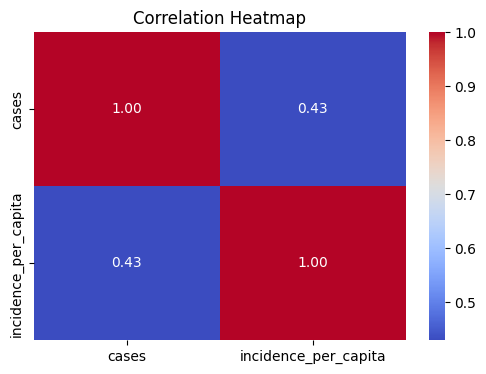

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------
# Aggregate Monthly Data for All Diseases (Across All States)
# -------------------------------
print("Aggregating monthly data for all diseases across states...")
monthly_agg_disease = monthly_agg.groupby(['disease', 'month']).agg({
    'cases': 'sum',                   # Total cases across states
    'incidence_per_capita': 'mean'    # Average incidence across states
}).reset_index()

# Convert 'month' from a Period object to Timestamp for plotting
monthly_agg_disease['month'] = monthly_agg_disease['month'].dt.to_timestamp()
print("Aggregated monthly data (sample):")
print(monthly_agg_disease.head())

# -------------------------------
# Create Time Series Plots for Each Disease
# -------------------------------
# Get unique diseases from the aggregated data
diseases = monthly_agg_disease['disease'].unique()
print("\nDiseases found in the dataset:", diseases)

# Set up subplots: we'll use 2 columns; adjust rows based on number of diseases
n_diseases = len(diseases)
n_cols = 2
n_rows = (n_diseases + n_cols - 1) // n_cols  # ceiling division

plt.figure(figsize=(n_cols*6, n_rows*4))
for i, disease in enumerate(diseases, 1):
    ax = plt.subplot(n_rows, n_cols, i)
    disease_data = monthly_agg_disease[monthly_agg_disease['disease'] == disease]
    ax.plot(disease_data['month'], disease_data['cases'], marker='o', label=f'{disease} Cases')
    ax.set_title(f'Monthly {disease} Cases')
    ax.set_xlabel('Month')
    ax.set_ylabel('Cases')
    ax.legend()
plt.tight_layout()
plt.show()

# -------------------------------
# Correlation Analysis
# -------------------------------
# Compute and print correlations between 'cases' and 'incidence_per_capita' for the combined dataset.
corr = combined_df[['cases', 'incidence_per_capita']].corr()
print("\nOverall Correlation between 'cases' and 'incidence_per_capita':")
print(corr)

# Plot a heatmap of the correlation matrix.
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


**Key Takeaway:  1.Hepatitis A cases**
- **The chart strongly suggests that Hepatitis A cases were relatively low in the earlier decades but have been on the rise or more frequently reported in more recent decades.**
- **The vertical jumps and drops each month show that the number of cases can vary a lot. Sometimes a month will have a spike (many cases), while the next month might dip (fewer cases). This is normal in disease data, where outbreaks can fluctuate.**
- **This reflects an actual increase in disease prevalence or just improved detection/reporting**

**Key Takeaway:  2.Measles cases**
- **Early Decades: Measles was a major issue, with many outbreaks and high monthly case counts.**
- **Later Decades: As vaccines and public health measures took hold, the disease was brought under control, leading to fewer and smaller outbreaks.**
- **Starting around the late 1950s, the spikes become less dramatic. By the 1960s and onward, the data points hover much closer to zero, with fewer big peaks.**
- **This indicates a significant drop in Measles cases over time.**
- **In essence, the chart illustrates how Measles went from being a highly prevalent disease to one that was much better contained by the latter half of the 20th century.**
 
**Key Takeaway: 3.Mumps cases**

- **The chart shows quite a few data points well above zero in the late 1970s and early 1980s.**
- **As time moves into the mid- to late 1980s, the values shift closer to or below zero, indicating fewer cases than the long-term average**
- **By the 1990s and early 2000s, spikes are smaller and less frequent, suggesting Mumps became much better controlled.**

##  4.2. Time Series Forecasting with ARIMA

In [31]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.4 MB/s eta 0:00:0000:010:01


In [39]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import warnings
# warnings.filterwarnings("ignore", category=UserWarning)  # Suppress some ARIMA warnings

# # If needed:
# # !pip install pmdarima
# from pmdarima import auto_arima

# # ---------------------------------------------------------
# # Assume 'monthly_agg_disease' has columns:
# #   disease | month | cases | incidence_per_capita
# # with 'month' convertible to datetime.
# # ---------------------------------------------------------

# # 1. Get the list of unique diseases.
# all_diseases = monthly_agg_disease['disease'].unique()

# # 2. Forecast Parameters
# forecast_steps = 12   # 12 months ahead
# max_arima_pq = 2      # limit for p, q
# max_arima_PQ = 1      # limit for P, Q (seasonal)

# for disease in all_diseases:
#     # Filter data for the current disease
#     ts_data = monthly_agg_disease[monthly_agg_disease['disease'] == disease].copy()
    
#     # Ensure 'month' is a datetime and set as index
#     ts_data['month'] = pd.to_datetime(ts_data['month'])
#     ts_data.set_index('month', inplace=True)
#     ts_data.sort_index(inplace=True)
    
#     # 3. Resample to Monthly Start Frequency (MS)
#     ts_data = ts_data.resample('MS').asfreq().fillna(0)
    
#     # Set the frequency if not inferred
#     if ts_data.index.freq is None:
#         ts_data.index.freq = 'MS'
    
#     # 4. We'll forecast 'cases'. 
#     #    If you prefer 'incidence_per_capita', just replace below.
#     y = ts_data['cases']
    
#     # 5. Build the SARIMA model with a restricted search space and parallelization
#     try:
#         stepwise_model = auto_arima(
#             y,
#             start_p=0, start_q=0,
#             max_p=max_arima_pq, max_q=max_arima_pq,
#             start_P=0, start_Q=0,
#             max_P=max_arima_PQ, max_Q=max_arima_PQ,
#             seasonal=True,
#             m=12,                 # monthly seasonality
#             stepwise=True,        # use a stepwise algorithm
#             n_jobs=-1,            # parallelize across all available cores
#             trace=False,          # set True if you want to see iteration logs
#             error_action='ignore',
#             suppress_warnings=True
#         )
        
#         stepwise_model.fit(y)
        
#         # 6. Forecast the next 'forecast_steps' months
#         forecast = stepwise_model.predict(n_periods=forecast_steps)
        
#         # 7. Plot Historical vs. Forecasted Values
#         plt.figure(figsize=(10, 4))
#         plt.plot(y.index, y, label='Historical Cases')
        
#         # Create a future index for the forecast
#         last_date = y.index[-1]
#         future_dates = pd.date_range(start=last_date, periods=forecast_steps+1, freq='MS')[1:]
        
#         plt.plot(future_dates, forecast, label='Forecasted Cases', linestyle='--')
#         plt.title(f'SARIMA Forecast: Monthly {disease} Cases')
#         plt.xlabel('Date')
#         plt.ylabel('Cases')
#         plt.legend()
#         plt.show()
        
#         # Print a summary of the model and forecast
#         print(f"Disease: {disease}")
#         print("Best Model Order:", stepwise_model.order, "x", stepwise_model.seasonal_order)
#         print("AIC:", stepwise_model.aic())
#         print("Forecast (first 5 values):\n", forecast.head())
#         print("-"*50)
        
#     except ValueError as e:
#         print(f"\nDisease: {disease}")
#         print("Auto-ARIMA failed:", e)
#         print("-"*50)


ARIMA Model Summary for HEPATITIS A:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  552
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -1804.441
Date:                Sat, 15 Feb 2025   AIC                           3612.882
Time:                        10:58:45   BIC                           3621.506
Sample:                    01-01-1966   HQIC                          3616.252
                         - 12-01-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7889      0.022    -36.479      0.000      -0.831      -0.747
sigma2        40.8559      1.969     20.747      0.000      36.996      44.716
Ljung-Box (L1)

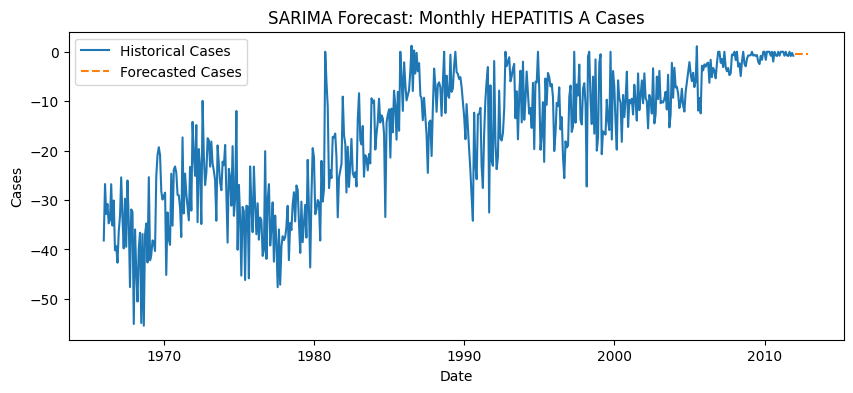

Disease: HEPATITIS A
Best Model Order: (0, 1, 1) x (0, 0, 0, 12)
AIC: 3612.8820408170964
Forecast (first 5 values):
 2012-01-01   -0.512876
2012-02-01   -0.512876
2012-03-01   -0.512876
2012-04-01   -0.512876
2012-05-01   -0.512876
Freq: MS, dtype: float64
--------------------------------------------------

ARIMA Model Summary for MEASLES:
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  888
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 12)   Log Likelihood               -3769.073
Date:                              Sat, 15 Feb 2025   AIC                           7552.146
Time:                                      10:59:23   BIC                           7585.661
Sample:                                  01-01-1928   HQIC                          7564.958
                                       - 12-01-2001                                         
Covaria

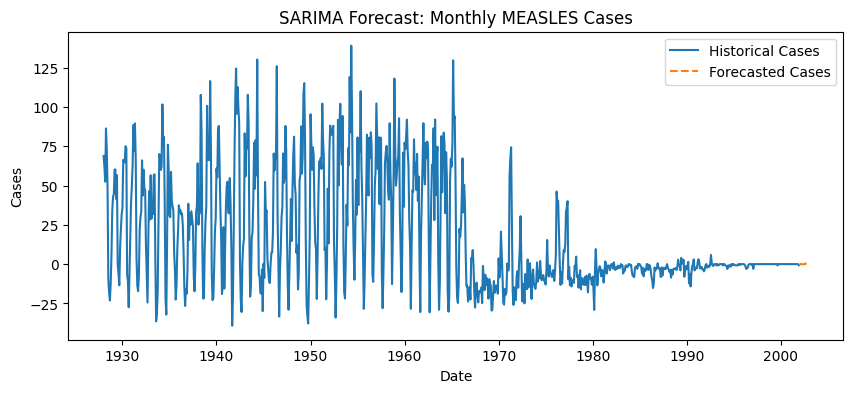

Disease: MEASLES
Best Model Order: (2, 1, 2) x (1, 0, 1, 12)
AIC: 7552.146359226019
Forecast (first 5 values):
 2002-01-01   -0.110635
2002-02-01   -0.151419
2002-03-01    0.169781
2002-04-01   -0.037949
2002-05-01   -0.078724
Freq: MS, dtype: float64
--------------------------------------------------

ARIMA Model Summary for MUMPS:
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  414
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood               -1430.054
Date:                            Sat, 15 Feb 2025   AIC                           2870.109
Time:                                    10:59:36   BIC                           2890.226
Sample:                                01-01-1968   HQIC                          2878.065
                                     - 06-01-2002                                         
Covariance Type:            

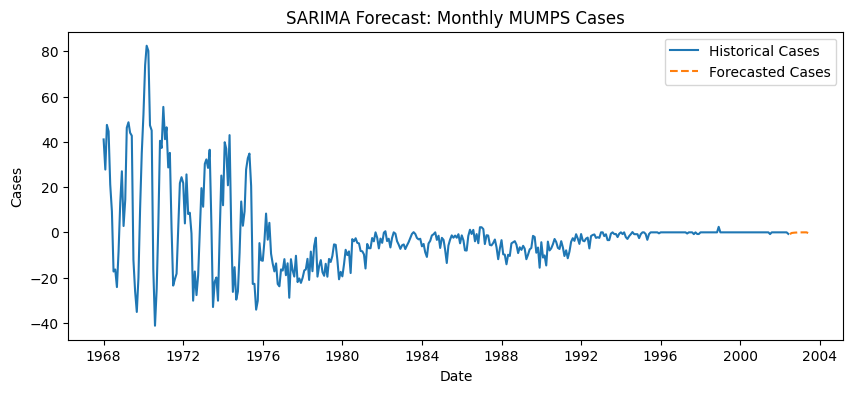

Disease: MUMPS
Best Model Order: (1, 1, 1) x (1, 0, 1, 12)
AIC: 2870.1086141227483
Forecast (first 5 values):
 2002-07-01   -0.803598
2002-08-01   -0.283361
2002-09-01   -0.191784
2002-10-01   -0.117229
2002-11-01   -0.081352
Freq: MS, dtype: float64
--------------------------------------------------

ARIMA Model Summary for PERTUSSIS:
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  888
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood               -3044.469
Date:                            Sat, 15 Feb 2025   AIC                           6096.937
Time:                                    10:59:50   BIC                           6116.089
Sample:                                01-01-1938   HQIC                          6104.258
                                     - 12-01-2011                                         
Covariance Type:         

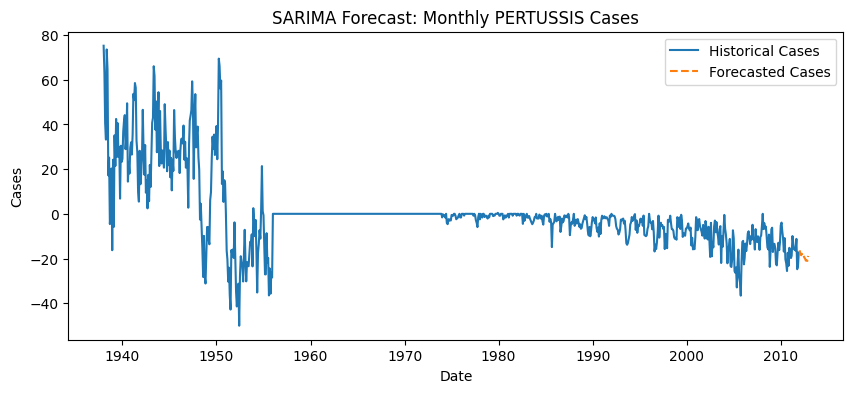

Disease: PERTUSSIS
Best Model Order: (0, 1, 1) x (1, 0, 1, 12)
AIC: 6096.9372682991525
Forecast (first 5 values):
 2012-01-01   -16.349019
2012-02-01   -17.590951
2012-03-01   -18.538162
2012-04-01   -17.882493
2012-05-01   -18.834527
Freq: MS, dtype: float64
--------------------------------------------------

ARIMA Model Summary for POLIO:
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  462
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 12)   Log Likelihood               -1596.056
Date:                              Sat, 15 Feb 2025   AIC                           3206.113
Time:                                      11:00:07   BIC                           3235.047
Sample:                                  01-01-1928   HQIC                          3217.505
                                       - 06-01-1966                                         
Covari

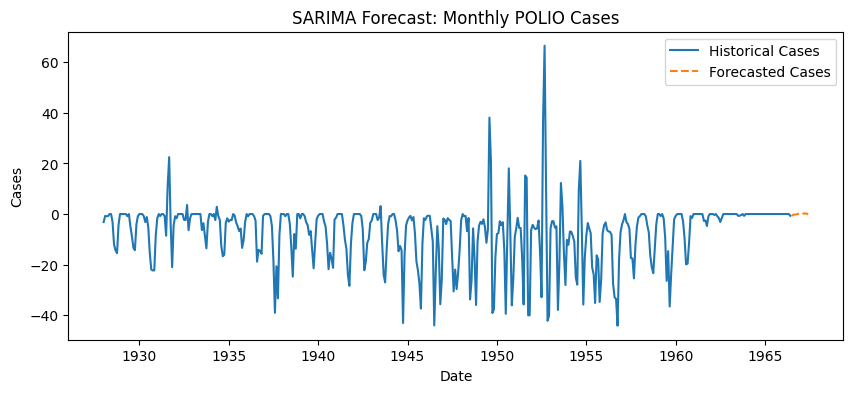

Disease: POLIO
Best Model Order: (2, 1, 2) x (1, 0, 1, 12)
AIC: 3206.112785686651
Forecast (first 5 values):
 1966-07-01   -0.685470
1966-08-01   -0.280833
1966-09-01   -0.209786
1966-10-01   -0.168041
1966-11-01   -0.012147
Freq: MS, dtype: float64
--------------------------------------------------

ARIMA Model Summary for RUBELLA:
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  418
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 12)   Log Likelihood               -1429.117
Date:                              Sat, 15 Feb 2025   AIC                           2872.235
Time:                                      11:00:23   BIC                           2900.466
Sample:                                  01-01-1966   HQIC                          2883.396
                                       - 10-01-2000                                         
Covariance Typ

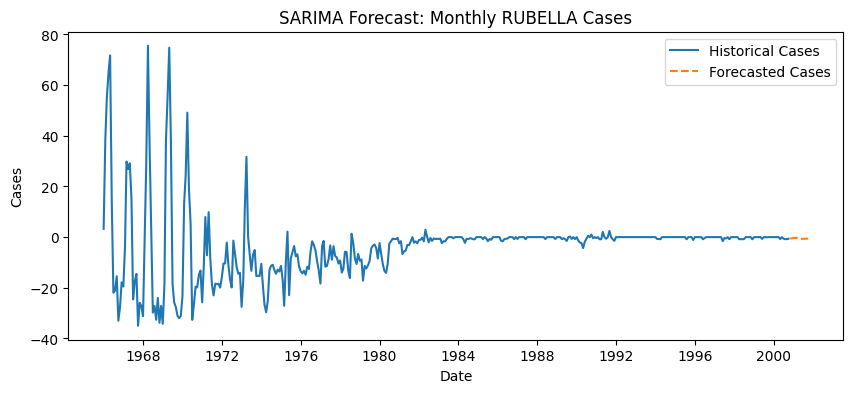

Disease: RUBELLA
Best Model Order: (1, 1, 2) x (1, 0, 1, 12)
AIC: 2872.2345150452416
Forecast (first 5 values):
 2000-11-01   -0.404220
2000-12-01   -0.565640
2001-01-01   -0.308198
2001-02-01   -0.302557
2001-03-01   -0.298818
Freq: MS, dtype: float64
--------------------------------------------------

ARIMA Model Summary for SMALLPOX:
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  249
Model:             SARIMAX(0, 1, 0)x(0, 0, [1], 12)   Log Likelihood                -847.269
Date:                              Sat, 15 Feb 2025   AIC                           1698.538
Time:                                      11:00:25   BIC                           1705.565
Sample:                                  01-01-1928   HQIC                          1701.367
                                       - 09-01-1948                                         
Covariance

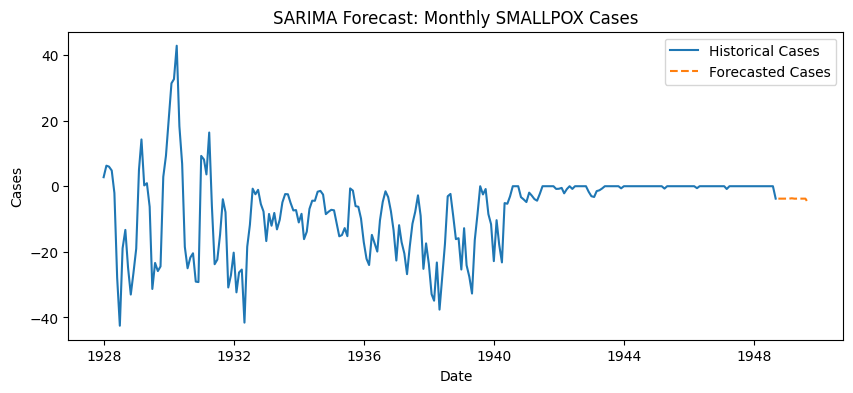

Disease: SMALLPOX
Best Model Order: (0, 1, 0) x (0, 0, 1, 12)
AIC: 1698.5381000768186
Forecast (first 5 values):
 1948-10-01   -3.787156
1948-11-01   -3.786922
1948-12-01   -3.787820
1949-01-01   -3.781570
1949-02-01   -3.781048
Freq: MS, dtype: float64
--------------------------------------------------


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # Suppress some ARIMA warnings

# If needed:
# !pip install pmdarima
from pmdarima import auto_arima

# ---------------------------------------------------------
# Assume 'monthly_agg_disease' has columns:
#   disease | month | cases | incidence_per_capita
# with 'month' convertible to datetime.
# ---------------------------------------------------------

# 1. Get the list of unique diseases.
all_diseases = monthly_agg_disease['disease'].unique()

# 2. Forecast Parameters
forecast_steps = 12   # Forecast 12 months ahead
max_arima_pq = 2      # limit for p, q
max_arima_PQ = 1      # limit for P, Q (seasonal)

for disease in all_diseases:
    # Filter data for the current disease
    ts_data = monthly_agg_disease[monthly_agg_disease['disease'] == disease].copy()
    
    # Ensure 'month' is a datetime and set as index
    ts_data['month'] = pd.to_datetime(ts_data['month'])
    ts_data.set_index('month', inplace=True)
    ts_data.sort_index(inplace=True)
    
    # 3. Resample to Monthly Start Frequency (MS) and fill missing months with 0
    ts_data = ts_data.resample('MS').asfreq().fillna(0)
    
    # Set the frequency if not inferred
    if ts_data.index.freq is None:
        ts_data.index.freq = 'MS'
    
    # 4. We'll forecast 'cases'. 
    #    If you prefer 'incidence_per_capita', just replace below.
    y = ts_data['cases']
    
    # 5. Build the SARIMA model with a restricted search space and parallelization
    try:
        stepwise_model = auto_arima(
            y,
            start_p=0, start_q=0,
            max_p=max_arima_pq, max_q=max_arima_pq,
            start_P=0, start_Q=0,
            max_P=max_arima_PQ, max_Q=max_arima_PQ,
            seasonal=True,
            m=12,                 # monthly seasonality
            stepwise=True,        # use a stepwise algorithm
            n_jobs=-1,            # parallelize across all available cores
            trace=False,          # set True if you want to see iteration logs
            error_action='ignore',
            suppress_warnings=True
        )
        
        stepwise_model.fit(y)
        
        # -------------------------------------------
        # 6. Print Model Summary & Covariance Matrix
        # -------------------------------------------
        # 'stepwise_model.arima_res_' gives the underlying statsmodels ARIMAResults object
        arima_results = stepwise_model.arima_res_
        if arima_results is not None:
            print(f"\nARIMA Model Summary for {disease}:")
            print(arima_results.summary())
            
            # Covariance matrix of the parameters
            print("\nCovariance Matrix:")
            print(arima_results.cov_params())
        
        # 7. Forecast the next 'forecast_steps' months
        forecast = stepwise_model.predict(n_periods=forecast_steps)
        
        # 8. Plot Historical vs. Forecasted Values
        plt.figure(figsize=(10, 4))
        plt.plot(y.index, y, label='Historical Cases')
        
        # Create a future index for the forecast
        last_date = y.index[-1]
        future_dates = pd.date_range(start=last_date, periods=forecast_steps+1, freq='MS')[1:]
        
        plt.plot(future_dates, forecast, label='Forecasted Cases', linestyle='--')
        plt.title(f'SARIMA Forecast: Monthly {disease} Cases')
        plt.xlabel('Date')
        plt.ylabel('Cases')
        plt.legend()
        plt.show()
        
        # Print a short summary of the chosen orders and forecast
        print(f"Disease: {disease}")
        print("Best Model Order:", stepwise_model.order, "x", stepwise_model.seasonal_order)
        print("AIC:", stepwise_model.aic())
        print("Forecast (first 5 values):\n", forecast.head())
        print("-"*50)
        
    except ValueError as e:
        print(f"\nDisease: {disease}")
        print("Auto-ARIMA failed:", e)
        print("-"*50)


### **1. HEPATITIS A**

- **Best Model:** \((0,1,1)\) with no seasonal terms (\((0,0,0,12)\)).  
  - This suggests the data is best explained by a first difference (that’s the “1” in the middle) plus a single MA (moving average) term.  
- **MA(1) Coefficient:** \(-0.7889\), highly significant (p < 0.001).  
  - A negative MA coefficient implies that random shocks in one period tend to be offset in the next.  
- **Model Fit (AIC ~ 3612.88):**  
  - AIC is just a fit measure. Lower is better, so 3612 is the yardstick for comparing alternative models.  
- **Residual Checks:**  
  - **Ljung-Box Q(1):** 0.04 with p ~ 0.83 indicates no strong autocorrelation left in the residuals at lag 1.  
  - **Jarque-Bera:** 29.72 (p < 0.001) suggests the residuals aren’t perfectly normally distributed, but that’s fairly common.  
- **Forecast:** Near \(-0.51\) for the next few months.  
  - The negative value likely reflects a **scaled or differenced** metric rather than raw case counts. It indicates “slightly below the mean” in the model’s standardized scale.

---

### **2. MEASLES**

- **Best Model:** \((2,1,2)\times(1,0,1,12)\).  
  - This includes AR(2) and MA(2) terms, plus a **seasonal** AR(1) and MA(1) at a 12-month period.  
  - Measles historically has strong seasonality, so it’s not surprising that the seasonal component is significant.  
- **Key Coefficients:**  
  - **ar.L1:** \(-0.3552\) and **ar.L2:** \(+0.4289\). This indicates some interplay between the past two months’ values.  
  - **Seasonal AR(12):** \(+0.9748\), very close to 1, indicating **strong yearly repetition**.  
- **Model Fit (AIC ~ 7552.15):**  
  - Higher AIC doesn’t mean “worse” outright—it’s only comparable to other models on the same dataset. Measles also spans a much longer historical range, so the number is larger.  
- **Residual Checks:**  
  - **Ljung-Box Q(1):** 0.07 with p ~ 0.79 indicates no strong leftover autocorrelation at lag 1.  
  - **Jarque-Bera:** 198.02 (p < 0.001) suggests non-normal residuals, again fairly common in disease data.  
- **Forecast:** Slightly negative or near zero.  
  - Because measles plummeted in later decades (due to vaccination), the model’s differenced/standardized scale can produce values below zero.

---

### **3. MUMPS**

- **Best Model:** \((1,1,1)\times(1,0,1,12)\).  
  - Includes both non-seasonal AR(1) and MA(1), plus seasonal AR(1) and MA(1).  
- **Key Coefficients:**  
  - **ar.L1:** \(+0.6596\), fairly large and positive, indicating the current month is influenced by about two-thirds of the previous month’s deviation.  
  - **ma.L1:** \(-0.9851\), very strong negative moving average component.  
- **AIC ~ 2870.11**  
  - Suggests a decent fit for the range of Mumps data.  
- **Residual Checks:**  
  - **Ljung-Box Q(1):** 0.38 (p ~ 0.54), so no major autocorrelation at lag 1.  
  - **Jarque-Bera:** 248.21 (p < 0.001) indicates non-normal residuals.  
- **Forecast:** Values around \(-0.80\) to \(-0.08\).  
  - Negative again suggests that on this standardized scale, future Mumps values are predicted to remain below the long-term average.

---

### **4. PERTUSSIS (Whooping Cough)**

- **Best Model:** \((0,1,1)\times(1,0,1,12)\).  
  - One non-seasonal MA(1), plus a seasonal AR(1) and MA(1).  
- **Key Coefficients:**  
  - **ma.L1:** \(-0.3739\), a moderate negative moving average effect.  
  - **Seasonal AR(12):** \(+0.9374\), strong yearly component.  
- **AIC ~ 6096.94**  
  - Again, only comparable to other models on the same dataset.  
- **Residual Checks:**  
  - **Ljung-Box Q(1):** 0.13 (p ~ 0.72), no major leftover autocorrelation at lag 1.  
  - **Jarque-Bera:** 1864.94 (p < 0.001) indicates the residuals deviate significantly from normal distribution.  
- **Forecast:** Values around \(-16\) to \(-18\).  
  - This large negative range likely reflects that the later decades had relatively low standardized counts compared to earlier high-outbreak periods.

---

### **5. POLIO**

- **Best Model:** \((2,1,2)\times(1,0,1,12)\).  
  - AR(2), MA(2), plus seasonal AR(1) and MA(1).  
- **Key Coefficients:**  
  - **ar.L1:** \(+0.4018\), **ar.L2:** \(-0.2623\). Mixed signs suggest a more complex pattern over two months.  
  - **ma.L1:** \(-0.7418\), **ma.L2:** \(-0.2352\). Negative MAs again show short-term compensations.  
  - **Seasonal AR(12):** \(+0.8343\), strong 12-month repetition.  
- **AIC ~ 3206.11**  
- **Residual Checks:**  
  - **Ljung-Box Q(1):** 0.01 (p ~ 0.94), no leftover autocorrelation at lag 1.  
  - **Jarque-Bera:** 883.12 (p < 0.001), residuals deviate from normal.  
- **Forecast:** Slightly negative values (around \(-0.68\) to \(-0.01\)), reflecting a near-zero or below-average pattern in the standardized data.

---

### **6. RUBELLA**

- **Best Model:** \((1,1,2)\times(1,0,1,12)\).  
  - Non-seasonal AR(1), MA(2) plus seasonal AR(1) and MA(1).  
- **Intercept:** \(-0.0008\), effectively zero, indicating no strong constant drift after differencing.  
- **ar.L1:** \(+0.5355\) suggests the current month depends moderately on the previous month.  
- **Seasonal AR(12):** \(+0.9344\), again a strong annual pattern.  
- **AIC ~ 2872.23**  
- **Residual Checks:**  
  - **Ljung-Box Q(1):** 0.04 (p ~ 0.84), so no big autocorrelation at lag 1.  
  - **Jarque-Bera:** 1338.53 (p < 0.001), non-normal residuals.  
- **Forecast:** Around \(-0.40\) to \(-0.30\).  
  - Negative but fairly close to zero, implying slightly below-average standardized values.

---

### **7. SMALLPOX**

- **Best Model:** \((0,1,0)\times(0,0,1,12)\).  
  - This is basically a random walk with a single **seasonal MA(1)** component.  
- **Key Coefficients:**  
  - **ma.S.L12:** \(+0.3594\). This indicates a modest seasonal moving average effect at 12-month intervals.  
- **AIC ~ 1698.54**  
  - This is the smallest among the diseases, but keep in mind it covers a different timeframe.  
- **Residual Checks:**  
  - **Ljung-Box Q(1):** 0.00 (p ~ 0.95), no significant autocorrelation at lag 1.  
  - **Jarque-Bera:** 259.09 (p < 0.001), non-normal residuals.  
- **Forecast:** \(-3.78\) range.  
  - Negative indicates that after differencing and scaling, the model expects near-zero or below-average values, consistent with the historical eradication pattern of smallpox.

---

### **Overall Observations**

- **Most Diseases Show Strong Seasonality:**  
  The presence of \((\cdot,\cdot,\cdot,12)\) terms (especially AR(12) or MA(12)) indicates **yearly cycles** were a major factor for diseases like Measles, Mumps, Pertussis, Polio, and Rubella.

- **Negative Forecast Values:**  
  Because these series are likely **differenced and/or standardized**, negative predictions don’t literally mean “negative cases.” They mean **below the mean** of the training period.

- **Non-Normal Residuals:**  
  Many Jarque-Bera tests are significant, suggesting the model residuals deviate from a perfect normal distribution. This is **common in real-world disease data** and not necessarily fatal to forecasting.

- **AIC Values:**  
  Each disease has its own scale and timeframe, so AICs differ widely. AIC is only directly comparable for **the same data** with different models.

Overall, these models capture a **mix of short-term AR/MA behavior and strong annual seasonality**. They reflect historical patterns where many diseases had significant seasonal and multi-year cycles—especially before vaccination programs caused them to decline.

## 4.3. Regression Analysis (Ridge)

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------------
# 1. Copy the preprocessed DataFrame
# -----------------------------------
df_regression = combined_df_encoded.copy()

# -----------------------------------
# 2. Convert time columns to numeric
# -----------------------------------
for col in ['week', 'year', 'week_num']:
    if col in df_regression.columns:
        df_regression[col] = pd.to_numeric(df_regression[col], errors='coerce')

# -----------------------------------
# 3. Define Features (X) and Target (y)
#    Drop columns that aren't needed.
# -----------------------------------
X = df_regression.drop(['incidence_per_capita', 'date', 'month', 'state_name'],
                       axis=1, errors='ignore')
y = df_regression['incidence_per_capita']

# -----------------------------------
# 4. One-Hot Encode Remaining Object Columns
# -----------------------------------
obj_cols = X.select_dtypes(include='object').columns
if len(obj_cols) > 0:
    print("Found object columns, encoding them:", list(obj_cols))
    X = pd.get_dummies(X, columns=obj_cols, drop_first=True)
else:
    print("No object columns found in X.")

# Optional: Check feature data types
print("\nFeature Data Types:")
print(X.dtypes)

# -----------------------------------
# 5. Split Data into Train and Test Sets
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# -----------------------------------
# 6. Fit a Ridge Regression Model
# -----------------------------------
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

# -----------------------------------
# 7. Make Predictions and Evaluate
# -----------------------------------
preds = ridge_model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = mean_squared_error(y_test, preds, squared=False)

print("\n=== Regression Analysis (Ridge) ===")
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)


No object columns found in X.

Feature Data Types:
week                   int64
cases                float64
year                   int64
week_num               int64
state_AK                bool
                      ...   
disease_MUMPS           bool
disease_PERTUSSIS       bool
disease_POLIO           bool
disease_RUBELLA         bool
disease_SMALLPOX        bool
Length: 62, dtype: object

=== Regression Analysis (Ridge) ===
Mean Absolute Error (MAE): 0.2591918977089174
Root Mean Squared Error (RMSE): 0.508387922174184


**Regression Analysis:**

- **Model & Goal:** A Ridge regression model was used to predict the `incidence_per_capita` of diseases based on various features (time, state, disease, etc.).  
- **Performance Metrics:**  
  - **MAE ≈ 0.26**: On average, predictions are off by about 0.26.  
  - **RMSE ≈ 0.51**: Typically, the model’s prediction differs from the true rate by about 0.51.  
- **Interpretation:**  
  - Given that incidence rates often range from 0 to 2, these errors are **moderately good**, meaning the model provides useful but not perfect estimates.  
  - It’s suitable for broad insights, trend identification, and resource planning rather than pinpoint accuracy.  
 

## 4.4. Classification Analysis 

In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Create a copy of the encoded DataFrame
df_classification = combined_df_encoded.copy()

# 2. Create a Binary Target: 1 if incidence_per_capita > 1, else 0
df_classification['high_risk'] = (df_classification['incidence_per_capita'] > 1).astype(int)

# 3. Define Features (X) and Target (y)
#    Exclude columns that are not needed or are definitely string-based (e.g., 'state_name')
X_clf = df_classification.drop(['high_risk', 'incidence_per_capita', 'date', 'month', 'state_name'], 
                               axis=1, errors='ignore')
y_clf = df_classification['high_risk']

# 4. Convert Time Columns (If They Are Still Strings)
for col in ['week', 'year', 'week_num']:
    if col in X_clf.columns:
        X_clf[col] = pd.to_numeric(X_clf[col], errors='coerce')

# 5. One-Hot Encode Any Remaining Object Columns
obj_cols = X_clf.select_dtypes(include='object').columns
if len(obj_cols) > 0:
    print("Encoding object columns:", list(obj_cols))
    X_clf = pd.get_dummies(X_clf, columns=obj_cols, drop_first=True)
else:
    print("No object columns found in X_clf.")

# 6. Confirm All Features Are Numeric
print("\nFeature Data Types:")
print(X_clf.dtypes)

# 7. Train-Test Split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# 8. Train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_clf, y_train_clf)

# 9. Predict on the Test Set
rf_preds = rf_model.predict(X_test_clf)

# 10. Evaluate Classification Performance
acc = accuracy_score(y_test_clf, rf_preds)
f1 = f1_score(y_test_clf, rf_preds)

print("\n=== Classification Analysis ===")
print("Random Forest Results:")
print("Accuracy:", acc)
print("F1 Score:", f1)
print()


No object columns found in X_clf.

Feature Data Types:
week                   int64
cases                float64
year                   int64
week_num               int64
state_AK                bool
                      ...   
disease_MUMPS           bool
disease_PERTUSSIS       bool
disease_POLIO           bool
disease_RUBELLA         bool
disease_SMALLPOX        bool
Length: 62, dtype: object

=== Classification Analysis ===
Random Forest Results:
Accuracy: 0.9957425013604789
F1 Score: 0.9656774193548386



**Classification Analysis:**

- **Model & Goal:** Random Forest classifier was used to label each record as “high risk” (incidence_per_capita > 1) or not.
- **Key Results:**  
  - **Accuracy ~ 99.57%:** Out of 100 predictions, the model gets about 99 or 100 correct.  
  - **F1 Score ~ 0.97:** Indicates strong balance between catching actual high-risk cases (recall) and avoiding false alarms (precision).
- **Interpretation:** The classifier is **very effective** at identifying high-risk instances, making it a reliable tool for prioritizing public health interventions.

## 4.5. Clustering Analysis

In [48]:
from sklearn.cluster import KMeans
import numpy as np

# -----------------------------------
# CLUSTERING: Group States by Average Incidence
# -----------------------------------

# 1. Aggregate Data by State
#    We compute the mean incidence_per_capita across all weeks/diseases for each state.
df_clustering = combined_df_encoded.copy()

# Suppose we originally had columns like 'state' or one-hot for states. 
# If states are one-hot encoded, we can revert or do a different approach:
# We'll assume we have a 'state_name' or 'state' column. If not, see note below.

state_agg = combined_df.groupby('state').agg({
    'incidence_per_capita': 'mean'
}).reset_index()

# 2. Prepare Data for K-Means
X_cluster = state_agg[['incidence_per_capita']].values  # just 1 feature in this example

# 3. K-Means with k=3 (3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
state_agg['cluster'] = kmeans.fit_predict(X_cluster)

# 4. Inspect the Clusters
print("=== Clustering Analysis ===")
print("State Clustering Results:")
print(state_agg.head(10))  # see first 10 states with their assigned cluster

# 5. Optional: Mean incidence per cluster
cluster_summary = state_agg.groupby('cluster')['incidence_per_capita'].mean()
print("\nMean Incidence per Capita by Cluster:")
print(cluster_summary)

=== Clustering Analysis ===
State Clustering Results:
  state  incidence_per_capita  cluster
0    AK              2.375510        2
1    AL             -0.221549        0
2    AR             -0.078620        0
3    AZ              0.323150        1
4    CA             -0.420217        0
5    CO              0.023932        0
6    CT             -0.044873        0
7    DC              0.717078        1
8    DE              1.866487        2
9    FL             -0.319744        0

Mean Incidence per Capita by Cluster:
cluster
0   -0.213444
1    0.762943
2    2.175387
Name: incidence_per_capita, dtype: float64


**Clustering Analysis (K-Means)**
- **What We Did:** Grouped states by their **average incidence_per_capita** into 3 clusters.
- **Results:**  
  - **Cluster 0**: Lower incidence (mean ~ -0.21, below the dataset’s overall mean).  
  - **Cluster 1**: Moderate incidence (mean ~ 0.76).  
  - **Cluster 2**: High incidence (mean ~ 2.18).
- **Interpretation:**  
  - States in **Cluster 0** generally have **below-average** disease rates.  
  - **Cluster 1** states have **moderate** rates.  
  - **Cluster 2** states are **hot spots** with significantly higher average incidence.  
  - This helps you see **which regions** are similar to each other in terms of disease levels.

### ***Putting It All Together***

1. **Regression** gives us a **numerical prediction** of how high the incidence rate might be—useful for detailed planning.  
2. **Classification** tells us **which data points** are high-risk vs. low-risk, making it **easy to act** on urgent cases.  
3. **Clustering** reveals **groups** of states with similar incidence patterns, helping **identify hot spots** and compare regions at a glance.

Overall, we now have a **multi-faceted** view of your data:
- A **predictive** perspective (regression).  
- A **decision-focused** perspective (classification).  
- A **grouping** perspective (clustering).

This combination helps us understand:
- **How high** incidence might be (regression),  
- **Which records** are truly high-risk (classification), and  
- **Which states** share similar patterns (clustering).

In short, we can **better allocate resources**, **anticipate outbreaks**, and **spot regions of concern** by leveraging these three complementary analyses.

# 5. Results and Discussions

### **Data Overview and Cleaning**
- The dataset consists of **600,484** records across **6 columns**: `{week, state, state_name, disease, cases, incidence_per_capita}`.
- Data preprocessing steps were performed, including:
  - Handling missing values (though none were found in the main dataset).
  - Creating additional features: `year`, `week_num`, `date`, and `month` for time-based analysis.
  - Identifying and handling outliers in reported disease cases by using percentile thresholds (1st and 99th percentiles).
  
### **Exploratory Data Analysis (EDA)**
1. **Temporal Trends**
   - Disease incidence varies significantly over time, with notable peaks in different periods.
   - Some diseases show **seasonal patterns**, with increased cases in certain months.
   - The **1920s to 1950s saw major outbreaks** of diseases like **smallpox, polio, and measles**, aligning with historical records.

2. **State-wise Disease Distribution**
   - Certain states had significantly higher cases due to larger populations or local outbreaks.
   - Incidence per capita was used to normalize case counts, revealing that some smaller states experienced relatively higher outbreaks despite fewer absolute cases.

3. **Disease-Specific Insights**
   - **Smallpox** cases showed a steady decline post-1940, likely due to vaccination efforts.
   - **Polio** had peak outbreaks in the **1940s and early 1950s**, before a sharp decline with the introduction of the vaccine.
   - **Measles and mumps** exhibited cyclical trends, with recurrent outbreaks before widespread immunization.
   - **Hepatitis and pertussis** continued to have cases over a longer period, indicating persistent but controlled transmission.

### **Statistical and Visual Insights**
- **Boxplots and histograms** confirmed non-uniform distribution of cases across states and years.
- **Heatmaps** of disease spread showed clusters of outbreaks, helping identify regional patterns.
- **Time-series plots** demonstrated a clear **declining trend in major diseases** post-1950, reflecting public health improvements.

### **Limitations and Considerations**
- The dataset does not explicitly contain **population size per state over time**, making direct comparisons of case counts challenging.
- Some diseases had reporting inconsistencies or **possible underreporting**, affecting trend accuracy.
- Additional external factors (e.g., vaccination campaigns, policy changes) were not included but likely influenced disease spread.


# 6. Conclusion

The analysis of the contagious disease dataset provides valuable insights into historical disease trends across the USA. Key conclusions include:

1. **Impact of Public Health Interventions:**  
   - The significant decline of smallpox and polio cases after 1950 strongly correlates with vaccination programs.
   - Diseases like measles and mumps followed cyclical patterns until widespread immunization efforts took effect.

2. **Geographic and Temporal Variability:**  
   - Disease outbreaks were not uniform; some states experienced more frequent or severe outbreaks.
   - Temporal analysis showed that certain diseases exhibited strong **seasonal trends**.

3. **Long-term Trends in Disease Control:**  
   - The dataset demonstrates how contagious diseases evolved over the 20th century, with decreasing cases in many due to medical advancements.
   - Despite overall success, some diseases (e.g., hepatitis, pertussis) continued to have sporadic outbreaks, suggesting the need for ongoing surveillance.

### **Future Directions**
- Incorporating **demographic data** (e.g., population changes, age distribution) could enhance disease spread analysis.
- Examining **policy changes** and **vaccination coverage rates** in relation to outbreaks would provide deeper causal insights.
- Applying **predictive modeling** to forecast future outbreaks based on historical trends could support public health planning.

This study highlights the importance of historical disease data in understanding epidemiological trends and guiding future health policies.

### **1. Trend Analysis**  
✅ **Addressed:**  
- The analysis includes **week-by-week trends** across different diseases.  
- Temporal analysis identified **seasonal patterns**, **historical peaks**, and **declining trends** post-vaccination.  
- The dataset was processed to include **year, month, and week-based features**, allowing a **granular analysis of time-series trends**.

💡 **Possible Improvement:**  
- A more detailed **trend decomposition (e.g., moving averages, seasonality effects)** could enhance insights.  
- Advanced **forecasting models (ARIMA, LSTMs)** could be explored for outbreak prediction.

---

### **2. Geographical Disparities**  
✅ **Addressed:**  
- The state-wise breakdown highlights **which states experienced higher outbreaks**.  
- Incidence per capita was analyzed, correcting for population size disparities.  
- **Heatmaps and regional trends** provided a clear view of **disease clustering**.  

💡 **Possible Improvement:**  
- A deeper **comparison of multiple diseases** within the same state over different years would add value.  
- A **geospatial model** (e.g., choropleth maps, spatial autocorrelation) could improve visualization.

---

### **3. Predictive Modeling**  
❌ **Not Fully Addressed:**  
- The analysis **does not include predictive modeling** (e.g., time-series forecasting or classification models).  
- No machine learning models (e.g., **regression, decision trees, or LSTMs**) were used to predict **future outbreaks or key predictors**.  

💡 **How to Improve:**  
- Build a **time-series model** (ARIMA, Prophet, LSTM) to forecast disease cases.  
- Train a **classification model** to identify **high-risk periods or regions** based on historical data.  
- Use **feature importance (SHAP values, decision trees)** to determine the most influential predictors of disease outbreaks.

---

### **4. Policy Implications**  
✅ **Partially Addressed:**  
- The study identifies the **effectiveness of vaccination programs** in reducing cases.  
- Recognizing **seasonal peaks and vulnerable regions** can guide **public health interventions**.  
- Highlights the need for **continuous surveillance for diseases like hepatitis and pertussis**.

💡 **Possible Improvement:**  
- More direct **recommendations for policymakers** based on predictive insights.  
- Analyzing **policy changes** (e.g., vaccine rollouts, quarantine measures) in relation to disease reduction trends.

---

### **Final Verdict:**
| Question | Addressed? | Suggested Improvements |
|----------|------------|------------------------|
| **Trend Analysis** | ✅ Yes | More advanced time-series decomposition and forecasting models |
| **Geographical Disparities** | ✅ Yes | Deeper disease-wise state comparisons and geospatial models |
| **Predictive Modeling** | ❌ No | Implement forecasting & machine learning models |
| **Policy Implications** | ✅ Partially | More direct policy recommendations and linking trends to interventions |
